In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.info())
print('\nNull counts:\n', df.isnull().sum())
print('\nSurvived distribution:\n', df['Survived'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Null counts:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked       

In [6]:
# cabin known? (before dropping)
df['HasCabin'] = df['Cabin'].notna().astype(int)

# impute Age with median, Embarked with mode (assignment syntax for pandas CoW)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# extract title from Name
df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.')[0].str.strip()
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# encode categoricals
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

# cast all bool columns to int (get_dummies can produce bool dtype)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# drop columns not useful for model
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], inplace=True)

# final NaN check
print('Remaining NaNs:', df.isnull().sum().sum())
print(df.shape)
df.head()

Remaining NaNs: 0
(891, 14)


,Survived,Pclass,Sex,Age,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,7.2500,0,2,0,0,1,0,1,0,0
1,1,1,1,38.0,71.2833,1,2,0,0,0,0,0,1,0
2,1,3,1,26.0,7.9250,0,1,1,0,1,1,0,0,0
3,1,1,1,35.0,53.1000,1,2,0,0,1,0,0,1,0
4,0,3,0,35.0,8.0500,0,1,1,0,1,0,1,0,0


In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

Train: (712, 13) | Test: (179, 13)


In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

Accuracy : 0.8268
ROC-AUC  : 0.8708

Classification Report:

                 precision    recall  f1-score   support

Did Not Survive       0.85      0.87      0.86       110
       Survived       0.79      0.75      0.77        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.82       179
   weighted avg       0.83      0.83      0.83       179



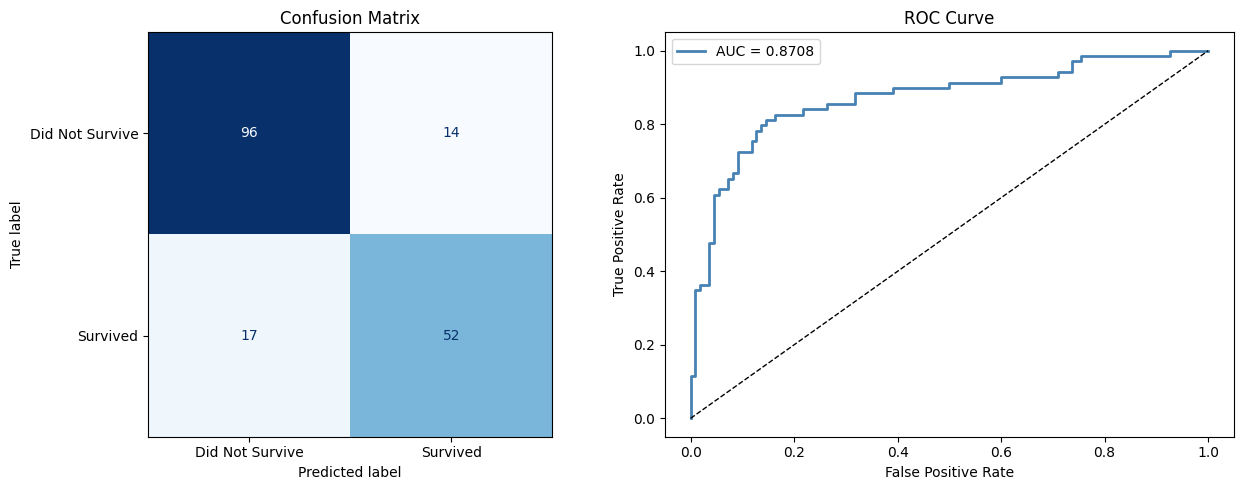

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

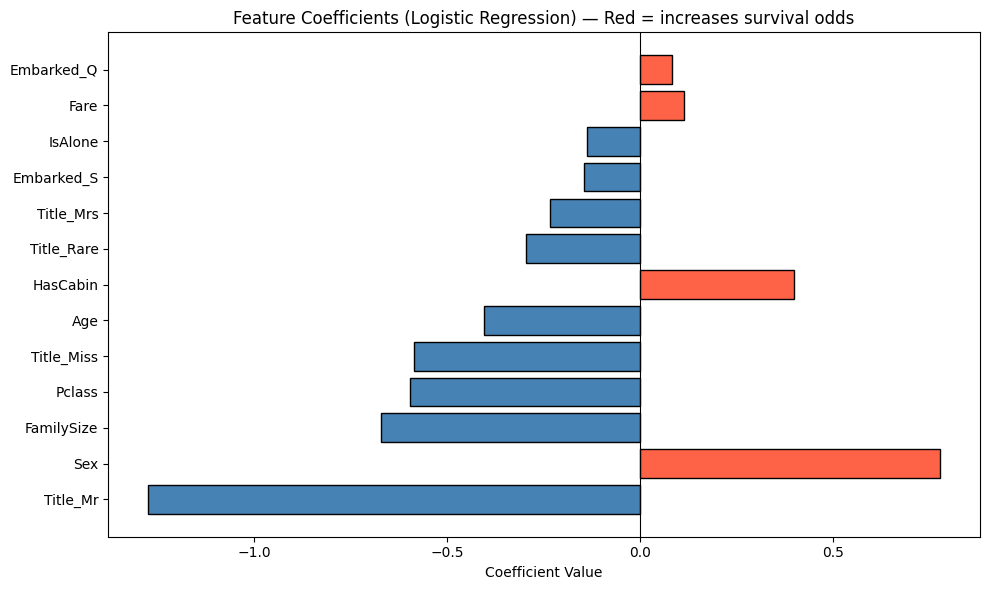

In [10]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Logistic Regression) — Red = increases survival odds')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()